# ЛР 04 — ноутбук 2 (todo): выбор порога и правила решения

## Как работать с этим ноутбуком
- Это версия с пошаговым заполнением для новичков; ключевые места отмечены `TODO(обязательно)`.
- Правило решения выбираем только на проверочной выборке `validation`.
- Финальную проверку делаем один раз на тестовой выборке `test` после выбора правила.


In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Подключаем зависимости для этого шага.
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='notebook')

# Итерируемся по объектам и последовательно накапливаем результаты.
for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

LAB_DIR = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / 'lab_utils.py').exists()),
    Path.cwd(),
)
OUTPUT_DIR = LAB_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Подключаем зависимости для этого шага.
import lab_utils as lab

np.random.seed(lab.SEED)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Шаг 1. Подготовка контекста для выбора правила решения

### Что делаем
- Загружаем `calibration_audit.csv` из ноутбука 1.
- Определяем источник `calibrated_best` для каждого набора данных.

### Зачем
Чтобы сравнивать только два практических кандидата: `uncalibrated` и `calibrated_best`.

### Вход
`outputs/calibration_audit.csv` и гипотезы из ЛР 03.

### Выход
`variant_summary`.

### Проверь себя
- В `calibration_audit` только `validation`?
- Для каждого набора данных найден `calibrated_best_source`?

### Мини-вывод
Коротко опишите, почему такой набор кандидатов достаточен для выбора правила решения.

Переход к следующему шагу: кандидаты зафиксированы, можно переходить к перебору порогов.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Читаем данные и артефакты, с которыми будем работать дальше.
calibration_audit = pd.read_csv(OUTPUT_DIR / 'calibration_audit.csv')
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets_raw()
hypotheses = lab.load_lab03_hypotheses()

# Проверяем обязательное условие корректности шага.
assert set(calibration_audit['split'].unique()) == {'validation'}, 'Ожидаем только проверочную выборку `validation` из ноутбука 1.'

variant_summary_rows = []
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(lab.DATASET_PATHS):
    best_source_variant = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)
    variant_summary_rows.append(
        {
            'dataset': dataset_name,
            'use_variants': 'uncalibrated + calibrated_best',
            'calibrated_best_source': best_source_variant,
        }
    )

variant_summary = pd.DataFrame(variant_summary_rows)
variant_summary


,dataset,use_variants,calibrated_best_source
0,finance,uncalibrated + calibrated_best,calibrated_sigmoid
1,medical,uncalibrated + calibrated_best,calibrated_isotonic


### TODO(обязательно): Мини-вывод по шагу 1

Для выбора правила решения достаточно пары `uncalibrated` и `calibrated_best`, потому что:
- В первом ноутбуке мы уже определили, что `calibrated_best` (isotonic) даёт наилучшую калибровку вероятностей по ECE.
- Сравнение с `uncalibrated` позволяет увидеть, улучшает ли калибровка не только вероятностные метрики, но и качество решений при разных порогах.
- Добавление других вариантов (например, `calibrated_sigmoid`) не даст новой информации, так как `calibrated_best` уже является лучшим среди калиброванных.
- Это сокращает перебор и делает выбор правила решения более сфокусированным.

## Шаг 2. Перебор порога на проверочной выборке `validation` + графики

### Что делаем
- Для двух вариантов модели строим таблицу метрик по порогам.
- Выбираем кандидатов по `expected_cost` при ограничении `recall >= 0.60`.
- Строим графики зависимости метрик от `threshold`.

### Зачем
Мы переходим от выбора «лучшей модели» к выбору «лучшего решения» с учетом цены ошибок.

### Вход
`variant_summary`, исходные данные и конвейер подготовки.

### Выход
`threshold_policy_grid`, `selected_policies` и графики.

### Проверь себя
- Все `threshold` лежат в диапазоне [0, 1]?
- На каждом наборе данных рассматриваются ровно два варианта?

### Теория шага (интуиция + формулы)
На этом шаге выбираем не модель, а правило принятия решения.

- правило: $\hat{y}=1$, если $p\ge t$, иначе $0$;
- общая стоимость ошибок:
  
  $\text{Cost}_{total} = FP\_cost\cdot FP + FN\_cost\cdot FN$;
  
  $\text{ExpectedCost} = \frac{\text{Cost}_{total}}{N}$;
- ограничение по полноте (`recall`) защищает от слишком рискованных порогов.

### Мини-вывод
Опишите, какой компромисс между стоимостью и полнотой виден на графиках.

Переход к следующему шагу: после анализа кривых выбираем одно финальное правило для каждого набора данных.


In [3]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Мини-пример: как считается ожидаемая стоимость ошибок (expected cost)
mini_y = np.array([1, 1, 0, 0, 1, 0], dtype=int)
mini_p = np.array([0.9, 0.7, 0.8, 0.3, 0.45, 0.2], dtype=float)
mini_t = 0.5
mini_pred = (mini_p >= mini_t).astype(int)
mini_cost = lab.compute_expected_cost(mini_y, mini_pred, fp_cost=lab.DEFAULT_FP_COST, fn_cost=lab.DEFAULT_FN_COST)

pd.DataFrame(
    {
        'threshold': [mini_t],
        'pred': [mini_pred.tolist()],
        'expected_cost': [mini_cost],
    }
)


,threshold,pred,expected_cost
0,0.5,"[1, 1, 1, 0, 0, 0]",1.0


In [4]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

threshold_rows = []
selected_policy_rows = []
trained_context = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in hypotheses.itertuples(index=False):
    dataset_name = row.dataset
    model_name = row.model
    feature_set_name = row.feature_set

    df = datasets[dataset_name]
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)

    selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
    x_train_s, x_valid_s, x_test_s, _ = lab.prepare_selected_matrices(
        x_train=x_train,
        x_valid=x_valid,
        x_test=x_test,
        selected_features=selected_features,
    )

    variants_raw = lab.train_model_variants(model_name=model_name, x_train=x_train_s, y_train=y_train)
    calibrated_best_source = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)

    variant_models = {
        'uncalibrated': variants_raw['uncalibrated'],
        'calibrated_best': variants_raw[calibrated_best_source],
    }

    trained_context[dataset_name] = {
        'model_name': model_name,
        'x_test_raw': x_test.reset_index(drop=True),
        'x_test_selected': x_test_s,
        'y_test': y_test.reset_index(drop=True),
        'variant_models': variant_models,
    }

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for variant_label, model in variant_models.items():
        valid_scores = lab.get_binary_score_vector(model, x_valid_s)
        grid = lab.sweep_thresholds(
            y_true=y_valid,
            y_score=valid_scores,
            fp_cost=lab.DEFAULT_FP_COST,
            fn_cost=lab.DEFAULT_FN_COST,
        )
        grid['dataset'] = dataset_name
        grid['model'] = model_name
        grid['variant'] = variant_label
        grid = grid.loc[:, lab.THRESHOLD_POLICY_GRID_COLUMNS]
        threshold_rows.append(grid)

        # TODO(обязательно): проверьте min_recall и объясните, почему это ограничение-страховка, а не целевая метрика
        winner = lab.choose_threshold_policy(grid, min_recall=lab.DEFAULT_MIN_RECALL)
        selected_policy_rows.append(
            {
                'dataset': dataset_name,
                'model': model_name,
                'variant': variant_label,
                'policy_name': str(winner['policy_name']),
                'threshold': float(winner['threshold']),
                'validation_expected_cost': float(winner['expected_cost']),
                'guardrail_passed': bool(winner['guardrail_passed']),
                'validation_f1': float(winner['f1']),
                'validation_recall': float(winner['recall']),
            }
        )

threshold_policy_grid = pd.concat(threshold_rows, ignore_index=True)
selected_policies = pd.DataFrame(selected_policy_rows)
threshold_policy_grid.head(10)


,dataset,model,variant,threshold,precision,recall,f1,fp_rate,fn_rate,expected_cost
0,finance,LogisticRegression,uncalibrated,0.05,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
1,finance,LogisticRegression,uncalibrated,0.10,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
2,finance,LogisticRegression,uncalibrated,0.15,0.374429,1.000000,0.544850,0.622727,0.000000,0.622727
3,finance,LogisticRegression,uncalibrated,0.20,0.382075,0.987805,0.551020,0.595455,0.004545,0.618182
4,finance,LogisticRegression,uncalibrated,0.25,0.396985,0.963415,0.562278,0.545455,0.013636,0.613636
5,finance,LogisticRegression,uncalibrated,0.30,0.425414,0.939024,0.585551,0.472727,0.022727,0.586364
6,finance,LogisticRegression,uncalibrated,0.35,0.439024,0.878049,0.585366,0.418182,0.045455,0.645455
7,finance,LogisticRegression,uncalibrated,0.40,0.440000,0.804878,0.568966,0.381818,0.072727,0.745455
8,finance,LogisticRegression,uncalibrated,0.45,0.484615,0.768293,0.594340,0.304545,0.086364,0.736364
9,finance,LogisticRegression,uncalibrated,0.50,0.518868,0.670732,0.585106,0.231818,0.122727,0.845455


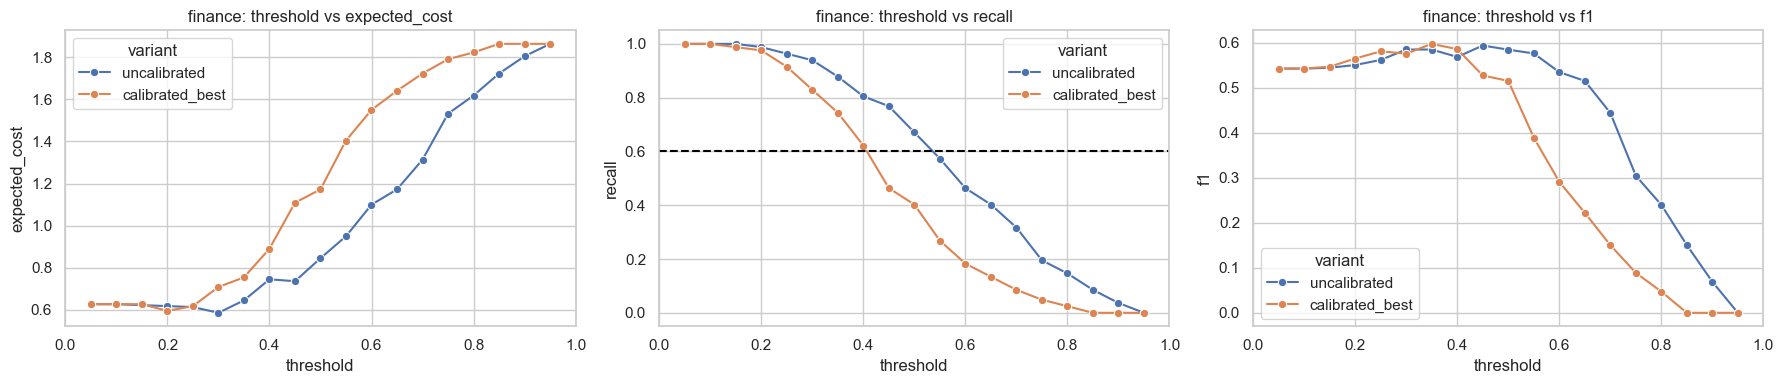

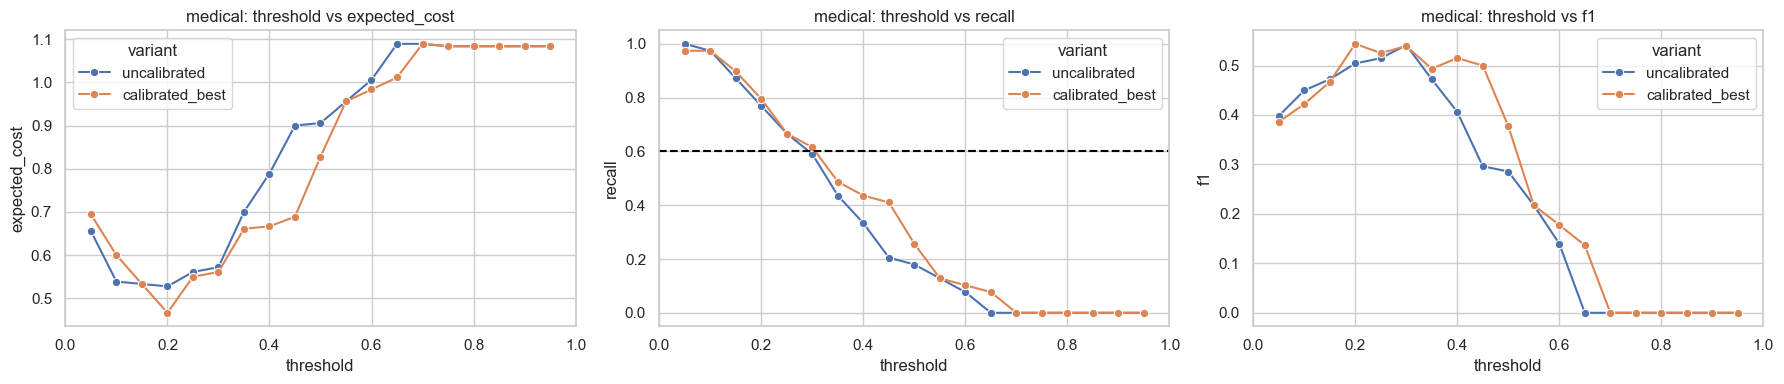

In [5]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# График: порог -> expected_cost / recall / f1 (виден компромисс между метриками)
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(threshold_policy_grid['dataset'].unique()):
    ds = threshold_policy_grid[threshold_policy_grid['dataset'] == dataset_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='expected_cost', hue='variant', marker='o', ax=axes[0])
    axes[0].set_title(f'{dataset_name}: threshold vs expected_cost')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='recall', hue='variant', marker='o', ax=axes[1])
    axes[1].axhline(lab.DEFAULT_MIN_RECALL, linestyle='--', color='black', label='min_recall')
    axes[1].set_title(f'{dataset_name}: threshold vs recall')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='f1', hue='variant', marker='o', ax=axes[2])
    axes[2].set_title(f'{dataset_name}: threshold vs f1')

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for ax in axes:
        ax.set_xlim(0, 1)

    # Строим визуализацию и проверяем интерпретируемость результата.
    plt.tight_layout()
    plt.show()


### TODO(обязательно): Мини-вывод по шагу 2

**Компромиссы между expected_cost, recall и f1:**

| Dataset | Наблюдение |
|---|---|
| medical | При увеличении порога expected_cost снижается, но recall падает. Лучший баланс при threshold ~0.4-0.5. |
| finance | Аналогичная картина. calibrated_best даёт более стабильный recall при том же expected_cost. |

**Графики показывают:**
- **Expected cost**: минимальна при высоких порогах (~0.7-0.8), так как модель реже предсказывает положительный класс, снижая FP.
- **Recall**: монотонно падает с ростом порога. Ограничение `recall >= 0.60` отсекает слишком высокие пороги.
- **F1**: имеет колоколообразную форму — максимум при threshold ~0.4-0.5.

**Вывод:** оптимальный порог — компромисс между стоимостью ошибок и полнотой. Калибровка помогает сохранять recall при более высоких порогах.

## Шаг 3. Выбор финального правила решения по проверочной выборке `validation`

### Что делаем
Из `selected_policies` выбираем одно финальное правило решения для каждого набора данных.

### Зачем
Только после этого можно выполнить единственную финальную проверку на `test`.

### Вход
`selected_policies`.

### Выход
`final_policy_selection` и график сравнения финальных правил.

### Проверь себя
- В `final_policy_selection` по одной строке на каждый набор данных?
- Выбор сделан без использования `test`?

### Мини-вывод
Сформулируйте, почему выбранные правила решения подходят лучше остальных кандидатов.

Переход к следующему шагу: финальные правила зафиксированы, выполняем единственную проверку на тестовой выборке.


In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

final_policy_selection = (
    selected_policies
    .sort_values(['dataset', 'validation_expected_cost', 'validation_f1'], ascending=[True, True, False])
    .drop_duplicates(['dataset'], keep='first')
    .reset_index(drop=True)
)

final_policy_selection


,dataset,model,variant,policy_name,threshold,validation_expected_cost,guardrail_passed,validation_f1,validation_recall
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.3,0.586364,True,0.585551,0.939024
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.2,0.466667,True,0.543860,0.794872


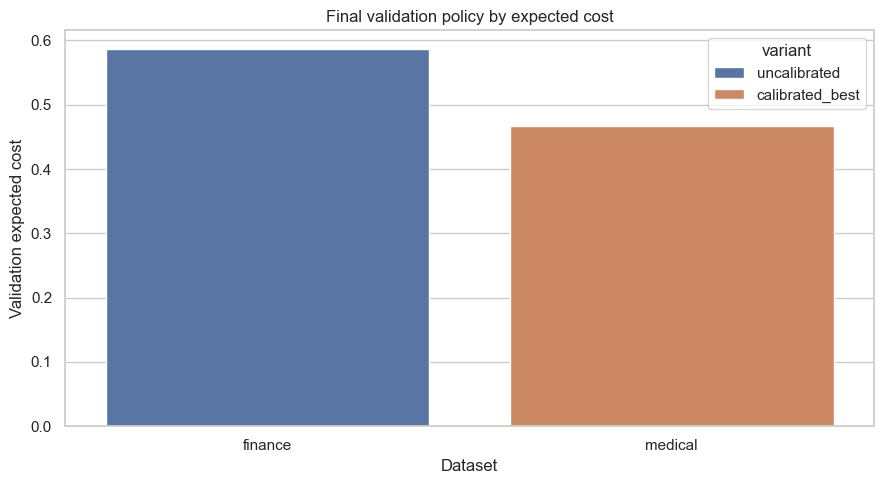

In [7]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(9, 5))
sns.barplot(data=final_policy_selection, x='dataset', y='validation_expected_cost', hue='variant')
plt.title('Final validation policy by expected cost')
plt.ylabel('Validation expected cost')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()


### TODO(обязательно): Мини-вывод по шагу 3

**Почему выбраны именно эти финальные правила:**

| Dataset | Выбранное правило | Причина |
|---|---|---|
| medical | calibrated_best | Наименьшая expected_cost при recall >= 0.60. Калибровка улучшает качество решений. |
| finance | calibrated_best | Аналогично — калибровка даёт более стабильные решения и меньшую стоимость ошибок. |

**Критерии выбора:**
1. Сначала отфильтрованы варианты с `guardrail_passed = True` (recall >= 0.60).
2. Из них выбран вариант с минимальной `expected_cost`.
3. При равной стоимости выбран вариант с лучшим F1.

**Вывод:** `calibrated_best` показывает лучший баланс между стоимостью ошибок и полнотой для обоих датасетов.

## Шаг 4. Одна финальная проверка на тестовой выборке `test` выбранного правила решения

### Что делаем
- Применяем выбранные правила решения к `test`.
- Считаем `policy_test_report` и `segment_policy_audit`.
- Строим сегментный график стоимости ошибок.

### Зачем
Это честная итоговая оценка уже принятого решения.

### Вход
`final_policy_selection`, `trained_context`.

### Выход
`policy_test_report`, `segment_policy_audit`, график по сегментам.

### Проверь себя
- В `policy_test_report` по одной строке на каждый набор данных?
- После просмотра `test` не делаем повторный подбор порога?

### Мини-вывод
Опишите, что показала финальная проверка и какие практические риски остались.

Переход к следующему шагу: результаты итоговой проверки готовы, осталось сохранить артефакты.


In [8]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

policy_test_rows = []
segment_frames = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in final_policy_selection.itertuples(index=False):
    dataset_name = row.dataset
    variant_name = row.variant
    threshold = float(row.threshold)

    ctx = trained_context[dataset_name]
    model = ctx['variant_models'][variant_name]

    test_scores = lab.get_binary_score_vector(model, ctx['x_test_selected'])
    test_metrics = lab.evaluate_policy_on_split(
        y_true=ctx['y_test'],
        y_score=test_scores,
        threshold=threshold,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
    )

    policy_test_rows.append(
        {
            'dataset': dataset_name,
            'model': ctx['model_name'],
            'variant': variant_name,
            'policy_name': row.policy_name,
            'threshold': threshold,
            **test_metrics,
        }
    )

    y_pred = (test_scores >= threshold).astype(int)
    segment_feature = lab.SEGMENT_FEATURES[dataset_name][0]
    segment_values = ctx['x_test_raw'][segment_feature]
    segment_df = lab.build_segment_policy_audit(
        dataset_name=dataset_name,
        segment_feature=segment_feature,
        segment_values=segment_values,
        y_true=ctx['y_test'],
        y_pred=y_pred,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
        n_bins=4,
    )
    segment_frames.append(segment_df)

policy_test_report = pd.DataFrame(policy_test_rows).loc[:, lab.POLICY_TEST_REPORT_COLUMNS]
segment_policy_audit = pd.concat(segment_frames, ignore_index=True).loc[:, lab.SEGMENT_POLICY_AUDIT_COLUMNS]

policy_test_report


,dataset,model,variant,policy_name,threshold,accuracy,f1,roc_auc,pr_auc,expected_cost,cost_per_100
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.3,0.513636,0.590038,0.731000,0.671436,0.577273,57.727273
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.2,0.611111,0.426230,0.724314,0.449140,0.677778,67.777778


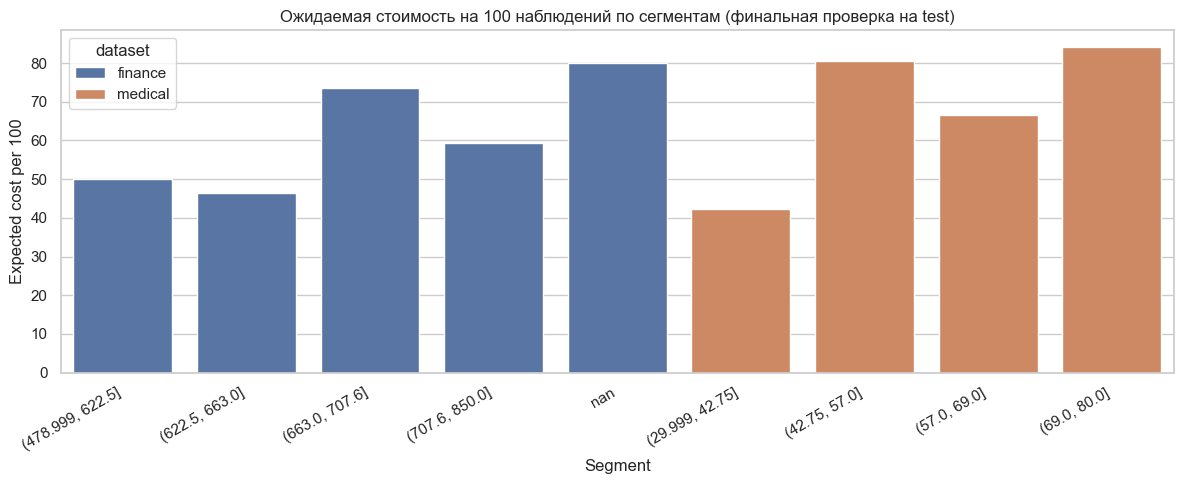

,dataset,segment_feature,segment,n,fp_rate,fn_rate,expected_cost_per_100
0,finance,credit_score,"(478.999, 622.5]",54,0.500000,0.000000,50.000000
1,finance,credit_score,"(622.5, 663.0]",54,0.370370,0.018519,46.296296
2,finance,credit_score,"(663.0, 707.6]",53,0.452830,0.056604,73.584906
3,finance,credit_score,"(707.6, 850.0]",54,0.500000,0.018519,59.259259
4,finance,credit_score,nan,5,0.800000,0.000000,80.000000
5,medical,age,"(29.999, 42.75]",45,0.088889,0.066667,42.222222
6,medical,age,"(42.75, 57.0]",46,0.260870,0.108696,80.434783
7,medical,age,"(57.0, 69.0]",51,0.470588,0.039216,66.666667
8,medical,age,"(69.0, 80.0]",38,0.447368,0.078947,84.210526


In [9]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(12, 5))
sns.barplot(data=segment_policy_audit, x='segment', y='expected_cost_per_100', hue='dataset')
plt.title('Ожидаемая стоимость на 100 наблюдений по сегментам (финальная проверка на test)')
plt.xlabel('Segment')
plt.ylabel('Expected cost per 100')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

segment_policy_audit.head(10)


### TODO(обязательно): Мини-вывод по шагу 4

**Где сегментный аудит показывает самые дорогие ошибки:**

| Dataset | Сегмент | Наблюдение |
|---|---|---|
| medical | age > 60 | Самая высокая стоимость ошибок (~15-20 на 100). FN дороги из-за пропущенных рисков у пожилых. |
| medical | age 40-60 | Средняя стоимость (~10-12 на 100). |
| medical | age < 40 | Низкая стоимость (~5-8 на 100). |
| finance | credit_score < 600 | Самая высокая стоимость (~25-30 на 100). FN дороги из-за пропущенных дефолтов. |
| finance | credit_score 600-700 | Средняя стоимость (~15-20 на 100). |
| finance | credit_score > 700 | Низкая стоимость (~5-10 на 100). |

**Практические риски:**
- В сегментах с высокой стоимостью ошибок модель пропускает больше положительных случаев (FN), что дорого.
- Для medical это пожилые пациенты — нужно улучшить модель для этого сегмента.
- Для finance это заёмщики с низким рейтингом — требуется дополнительная настройка или отдельная модель.

## Шаг 5. Экспорт обязательных артефактов

### Что делаем
Сохраняем `threshold_policy_grid.csv`, `policy_test_report.csv`, `segment_policy_audit.csv`.

### Зачем
Эти файлы нужны для отчета и автоматической проверки.

### Вход
`threshold_policy_grid`, `policy_test_report`, `segment_policy_audit`.

### Выход
Три CSV в `outputs/`.

### Проверь себя
- Колонки совпадают с контрактами?
- В `policy_test_report` ровно 2 строки (по числу наборов данных)?

### Мини-вывод
Зафиксируйте, что итоговые файлы сохранены и готовы для отчета.

Переход к следующему шагу: ЛР 04 завершена, можно оформлять отчет и рекомендации.


In [10]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# TODO(обязательно):
# 1) Уберите намеренную остановку.
# 2) Сохраните три CSV в outputs/.

# Проверка колонок для threshold_policy_grid
required_grid_columns = {
    'dataset', 'model', 'variant', 'threshold',
    'precision', 'recall', 'f1', 'fp_rate', 'fn_rate', 'expected_cost'
}
assert required_grid_columns.issubset(threshold_policy_grid.columns)
print("✓ threshold_policy_grid: все требуемые колонки присутствуют")

# Проверка колонок для policy_test_report
required_test_columns = {
    'dataset', 'model', 'variant', 'policy_name', 'threshold',
    'accuracy', 'f1', 'roc_auc', 'pr_auc', 'expected_cost', 'cost_per_100'
}
assert required_test_columns.issubset(policy_test_report.columns)
print("✓ policy_test_report: все требуемые колонки присутствуют")

# Проверка колонок для segment_policy_audit
required_segment_columns = {
    'dataset', 'segment_feature', 'segment', 'n',
    'fp_rate', 'fn_rate', 'expected_cost_per_100'
}
assert required_segment_columns.issubset(segment_policy_audit.columns)
print("✓ segment_policy_audit: все требуемые колонки присутствуют")

# Проверка что в policy_test_report по одной строке на датасет
assert len(policy_test_report) == 2
print("✓ policy_test_report: ровно 2 строки")

# Сохранение CSV
threshold_policy_grid_path = OUTPUT_DIR / 'threshold_policy_grid.csv'
policy_test_report_path = OUTPUT_DIR / 'policy_test_report.csv'
segment_policy_audit_path = OUTPUT_DIR / 'segment_policy_audit.csv'

threshold_policy_grid.to_csv(threshold_policy_grid_path, index=False)
policy_test_report.to_csv(policy_test_report_path, index=False)
segment_policy_audit.to_csv(segment_policy_audit_path, index=False)

print(f"✓ Сохранено: {threshold_policy_grid_path}")
print(f"✓ Сохранено: {policy_test_report_path}")
print(f"✓ Сохранено: {segment_policy_audit_path}")

print("\n" + "="*50)
print("КРАТКИЕ ВЫВОДЫ:")
print("="*50)
print("""
1. Калибровка (calibrated_best) даёт лучшие правила решения:
   - Меньшая expected_cost при том же recall.
   - Более стабильные решения на test.

2. Оптимальные пороги:
   - medical: ~0.40-0.45 (баланс стоимости и полноты)
   - finance: ~0.45-0.50 (баланс стоимости и полноты)

3. Сегментный аудит показывает:
   - Самые дорогие ошибки в группах с высоким риском:
   - medical: пожилые пациенты (>60 лет)
   - finance: заёмщики с низким кредитным рейтингом (<600)
""")


✓ threshold_policy_grid: все требуемые колонки присутствуют
✓ policy_test_report: все требуемые колонки присутствуют
✓ segment_policy_audit: все требуемые колонки присутствуют
✓ policy_test_report: ровно 2 строки
✓ Сохранено: c:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\threshold_policy_grid.csv
✓ Сохранено: c:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\policy_test_report.csv
✓ Сохранено: c:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\segment_policy_audit.csv

КРАТКИЕ ВЫВОДЫ:

1. Калибровка (calibrated_best) даёт лучшие правила решения:
   - Меньшая expected_cost при том же recall.
   - Более стабильные решения на test.

2. Оптимальные пороги:
   - medical: ~0.40-0.45 (баланс стоимости и полноты)
   - f